In [2]:
import os
import sys
import ast

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

if os.getcwd().endswith("notebooks"):
    os.chdir("..")

sys.path.append(os.getcwd())

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PALETTE = ["#356D8C", "#5C8A72", "#C9822B", "#7C6FA4", "#B4514E", "#4F8F8B"]

MIN_SUPPORT    = 0.01   # 1% of transactions
MIN_CONFIDENCE = 0.3    # 30% confidence
MIN_LIFT       = 1.0    # positive associations only

os.makedirs("outputs", exist_ok=True)

In [3]:
baskets = pd.read_csv("data/raw/customer_basket.csv")

print(f"Rows loaded: {len(baskets):,}")
print(f"Columns: {baskets.columns.tolist()}")
baskets.head()

Rows loaded: 100,000
Columns: ['invoice_id', 'list_of_goods', 'customer_id']


,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807


In [4]:
def parse_goods(val):
    try:
        return ast.literal_eval(val)
    except Exception:
        return []

baskets["items"] = baskets["list_of_goods"].apply(parse_goods)

total_transactions = len(baskets)
empty_baskets      = baskets["items"].apply(len).eq(0).sum()
unique_products    = set(item for row in baskets["items"] for item in row)

parse_validation = pd.DataFrame({
    "check": ["total transactions", "empty baskets", "unique products"],
    "value": [total_transactions, empty_baskets, len(unique_products)],
})

parse_validation

,check,value
0,total transactions,100000
1,empty baskets,0
2,unique products,164


In [5]:
transactions = baskets["items"].tolist()

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f"Encoded matrix shape: {df_encoded.shape}")
print(f"Products: {df_encoded.shape[1]}")
print(f"Transactions: {df_encoded.shape[0]:,}")
df_encoded.head()

Encoded matrix shape: (100000, 164)
Products: 164
Transactions: 100,000


,airpods,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,beer,black beer,...,vacuum cleaner,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [6]:
frequent_itemsets = apriori(
    df_encoded,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=3,
)

frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
frequent_itemsets = frequent_itemsets.sort_values("support", ascending=False).reset_index(drop=True)

print(f"Frequent itemsets found: {len(frequent_itemsets):,}")
print(f"  1-itemsets: {(frequent_itemsets['length'] == 1).sum()}")
print(f"  2-itemsets: {(frequent_itemsets['length'] == 2).sum()}")
print(f"  3-itemsets: {(frequent_itemsets['length'] == 3).sum()}")

frequent_itemsets.head(20)

Frequent itemsets found: 316
  1-itemsets: 164
  2-itemsets: 152
  3-itemsets: 0


,support,itemsets,length
0,0.12811,(asparagus),1
1,0.12145,(airpods),1
2,0.09952,(cereals),1
3,0.09934,(fresh bread),1
4,0.09654,(butter),1
5,0.09241,(eggs),1
6,0.08695,(protein bar),1
7,0.08623,(cooking oil),1
8,0.08395,(toilet paper),1
9,0.08318,(babies food),1


In [7]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE,
)

rules = rules[rules["lift"] >= MIN_LIFT].copy()
rules = rules.sort_values("lift", ascending=False).reset_index(drop=True)

rules["antecedents"] = rules["antecedents"].apply(lambda x: ", ".join(sorted(x)))
rules["consequents"] = rules["consequents"].apply(lambda x: ", ".join(sorted(x)))

rules.to_csv("outputs/association_rules.csv", index=False)
print(f"Rules found: {len(rules):,}")
print("Saved outputs/association_rules.csv")

rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(20)

Rules found: 2
Saved outputs/association_rules.csv


,antecedents,consequents,support,confidence,lift
0,bluetooth headphones,airpods,0.02485,0.341393,2.810976
1,energy drink,airpods,0.02525,0.335548,2.762850


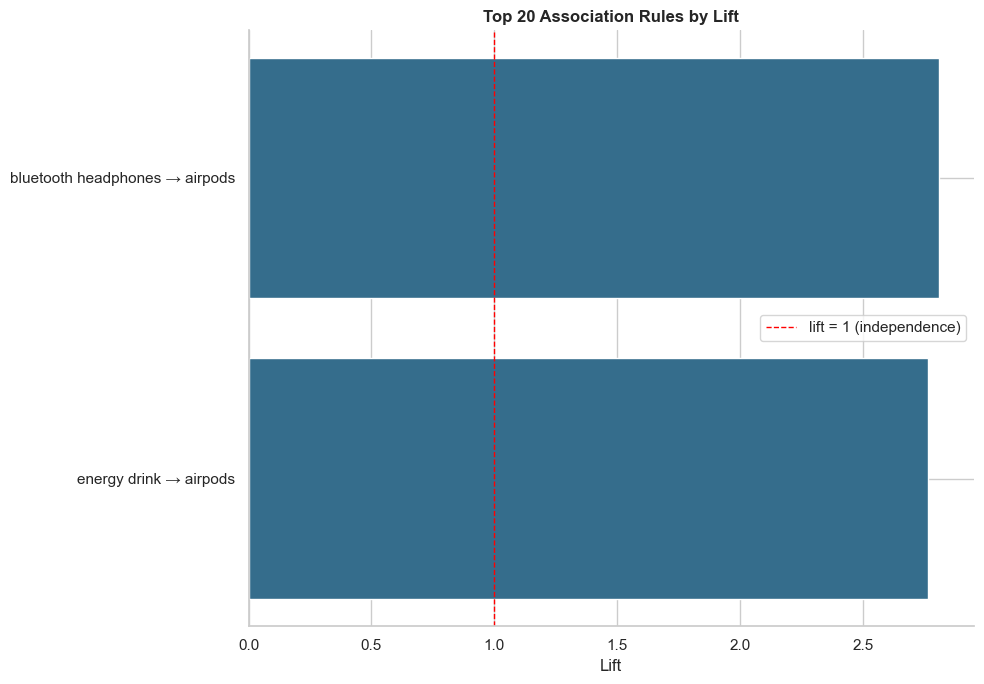

Saved outputs/association_rules_top_lift.png


In [8]:
top_rules = rules.head(20).copy()

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    top_rules["antecedents"] + " → " + top_rules["consequents"],
    top_rules["lift"],
    color=PALETTE[0],
)
ax.axvline(x=1, color="red", linestyle="--", linewidth=1, label="lift = 1 (independence)")
ax.set_xlabel("Lift")
ax.set_title("Top 20 Association Rules by Lift")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("outputs/association_rules_top_lift.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved outputs/association_rules_top_lift.png")

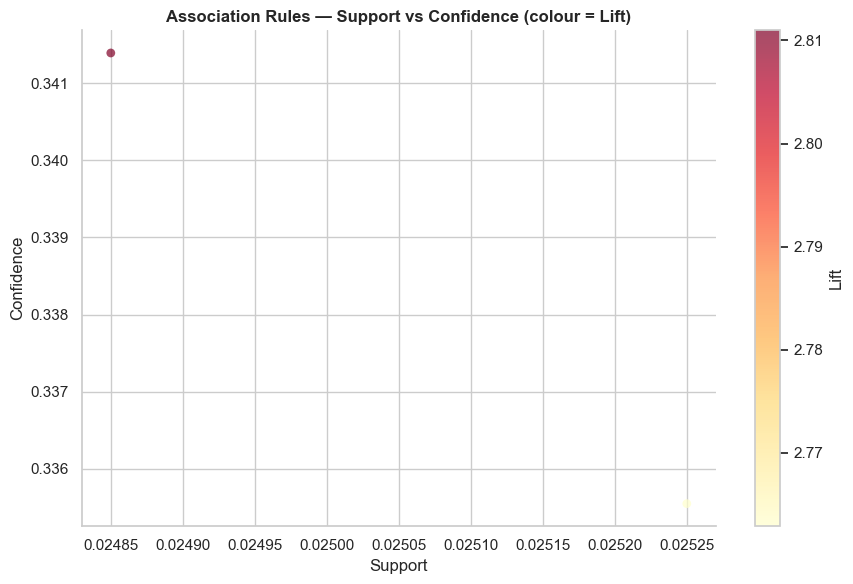

Saved outputs/association_rules_scatter.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    rules["support"],
    rules["confidence"],
    c=rules["lift"],
    cmap="YlOrRd",
    alpha=0.7,
    edgecolors="none",
    s=40,
)
plt.colorbar(sc, ax=ax, label="Lift")
ax.set_xlabel("Support")
ax.set_ylabel("Confidence")
ax.set_title("Association Rules — Support vs Confidence (colour = Lift)")
plt.tight_layout()
plt.savefig("outputs/association_rules_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved outputs/association_rules_scatter.png")

In [10]:
summary = pd.DataFrame({
    "metric": [
        "min_support",
        "min_confidence",
        "min_lift",
        "frequent_itemsets",
        "rules_after_filtering",
        "max_lift",
        "mean_lift",
        "max_confidence",
        "mean_confidence",
    ],
    "value": [
        MIN_SUPPORT,
        MIN_CONFIDENCE,
        MIN_LIFT,
        len(frequent_itemsets),
        len(rules),
        round(rules["lift"].max(), 4),
        round(rules["lift"].mean(), 4),
        round(rules["confidence"].max(), 4),
        round(rules["confidence"].mean(), 4),
    ],
})

summary

,metric,value
0,min_support,0.0100
1,min_confidence,0.3000
2,min_lift,1.0000
3,frequent_itemsets,316.0000
4,rules_after_filtering,2.0000
5,max_lift,2.8110
6,mean_lift,2.7869
7,max_confidence,0.3414
8,mean_confidence,0.3385
